# Copula scenario generation — build & validation

Estimates a **frozen Gaussian-copula** dependence structure over the 24-hour horizon and
turns the baseline forecaster's per-hour quantiles into coherent 24-hour prosumption
**scenarios** for the downstream dispatch optimiser.

Pipeline:

1. **Load** the frozen baseline forecaster and the gate-aligned 2018 windows.
2. **Forecast** the per-day quantile matrices `(N, 24, 19)`.
3. **PIT + probit** the realised errors and estimate the **annual copula correlation** `Σ` (the working choice; seasonal/EWMA left as future options).
4. **Freeze** the correlated Sobol draws `Z_corr` from `Σ`.
5. **`FrozenCopulaSampler`** — differentiable in the forecaster's quantiles, constant in `Σ`/draws — turns quantiles into scenarios.
6. **Validate** the scenarios: forecast/scenario plots, seasonal representative days, multivariate calibration.
7. **DFL-readiness checks**: `errors()` path, gradient flow, batched-over-days generation.

The sampler is the only part used live inside the DFL loop; everything above step 5 is
one-time estimation run before training.


## 1 · Setup

Imports, project paths, reproducibility.

In [32]:
import os
import sys
from pathlib import Path
from pyprojroot import here

import copy
import time
import random
import subprocess
import pickle

import numpy as np
import pandas as pd
from scipy.stats import norm
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
ROOT_DIR = here()
FORECASTING_DIR = ROOT_DIR / "4_forecasting"
DATA_DIR = ROOT_DIR / "1_data" / "processed"
COPULA_SAVE_DIR = ROOT_DIR / "5_scenario_gen"

sys.path.insert(0, str(FORECASTING_DIR))  # make forecasting module importable
sys.path.insert(0, str(COPULA_SAVE_DIR))  # make copula module importable

In [34]:
# tested core — same directory
from forecasting import (
    QUANTILE_LEVELS, HIST_COLS, FEAT_COLS, EXO_COLS,
    TRAIN_START, VAL_START, TEST_START, TEST_END,
    build_features, reindex_and_impute, make_windows,
    fit_scalers, normalise_hist, normalise_exo, normalise_y, denormalise_y,
    Baseline_Forecaster, pinball_loss,
)

In [35]:
# Copula core lives in copula_lib.py (same directory). It relies on
# FORECASTING_DIR being on sys.path, which was set two cells above.
from copula_lib import (
    MarginalDistCDF,
    build_probit_matrix,
    seasonal_correlation_matrices,
    plot_seasonal_correlations,
    build_Z_corr,
    FrozenCopulaSampler,
    prosumption_batched,
    scenario_calibration_check,
    quantile_reliability_check,
)

In [36]:
# ---- reproducibility (record SEED in the checkpoint) ----
SEED = 20240801
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| seed:", SEED)

device: cpu | seed: 20240801


## 2 · Load data and the frozen baseline forecaster

Rebuild the feature frame, load the checkpoint, and reconstruct the model from its saved
`model_config`. `QUANTILE_LEVELS`, the scaler, and the validation metric come from the
checkpoint so the copula uses exactly what the forecaster was trained with.

In [37]:
base_data = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"])
base_data.set_index("datetime", inplace=True)

base_data  = reindex_and_impute(base_data, HIST_COLS, freq="1h", warn_gap=6)
frame_full = build_features(base_data, feature_cols=FEAT_COLS)
print("frame_full:", frame_full.shape, "|", frame_full.index.min(), "->", frame_full.index.max())

[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
frame_full: (23520, 15) | 2017-11-03 00:00:00+00:00 -> 2020-07-09 23:00:00+00:00


In [38]:
# load in model checkpoint (weights + optimizer state + training metadata)
forecaster_checkpoint = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only = False, map_location="cpu")

In [39]:
forecaster_checkpoint.keys()

dict_keys(['state_dict', 'model_config', 'best_lr', 'scaler_stats', 'quantile_levels', 'split_dates', 'fixed_hparams', 'early_stopping', 'val_pinball', 'best_epoch', 'seed', 'git_sha', 'grid_results'])

In [40]:
model_config = forecaster_checkpoint["model_config"]
model = Baseline_Forecaster(**model_config) 

# 3. Load the trained weights into the model
model.load_state_dict(forecaster_checkpoint["state_dict"])

# 4. Set the model to evaluation mode before running inference
model.eval()

# 5. Extract ancillary data needed for inference or analysis
sc = forecaster_checkpoint["scaler_stats"]
QUANTILE_LEVELS = forecaster_checkpoint["quantile_levels"]
best_val_loss = forecaster_checkpoint["val_pinball"]
best_lr = forecaster_checkpoint["best_lr"]

## 3 · Gate-aligned windows and quantile forecasts

The copula is estimated on **gate-aligned daily origins** (`gate_aligned_only=True`,
one window per delivery day) — the same origin scheme the frozen artefacts and DFL use.
Run the forecaster once over every window to get the per-day quantile matrices.

In [41]:
#load data
h = pd.Timedelta(hours=1)

copula_windows = make_windows(
    frame_full, y_range=(TRAIN_START, VAL_START - h),
    gate_aligned_only=True, issue_hour=9,
    exo_cols=EXO_COLS, hist_cols=HIST_COLS, target_col="prosumption",
)

x_hist = copula_windows.x_hist
x_fut = copula_windows.x_fut

x_hist_n = normalise_hist(x_hist, sc)
x_fut_n = normalise_exo(x_fut, sc)

y = copula_windows.y
y_n = normalise_y(y, sc)
deliv_start = copula_windows.ds
deliv_end = copula_windows.de

In [42]:
deliv_start, deliv_end, x_hist.shape, x_fut.shape, y.shape

(Timestamp('2018-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2018-12-31 23:00:00+0000', tz='UTC'),
 (365, 168, 4),
 (365, 24, 9),
 (365, 24))

In [43]:
len(x_hist)

365

In [44]:
predictions = np.array([])

def _t(a):
    return torch.as_tensor(a, dtype=torch.float32, device=DEVICE)

preds = []
for x in range(len(x_hist)):
    with torch.no_grad():
        # remember: unsqueeze adds a dimension to the tensor, so that the model can process it as a batch of size 1
        out = model(_t(x_hist_n[x]).unsqueeze(0), _t(x_fut_n[x]).unsqueeze(0))
    preds.append(out.squeeze(0).cpu().numpy())   # (24, 19)
predictions = np.stack(preds, axis=0)            # (N, 24, 19) — explicit, no reshape guesswork


print ("predictions.shape:", predictions.shape, "| y.shape:", y.shape)

predictions.shape: (365, 24, 19) | y.shape: (365, 24)


qp.shape: (8760, 19)


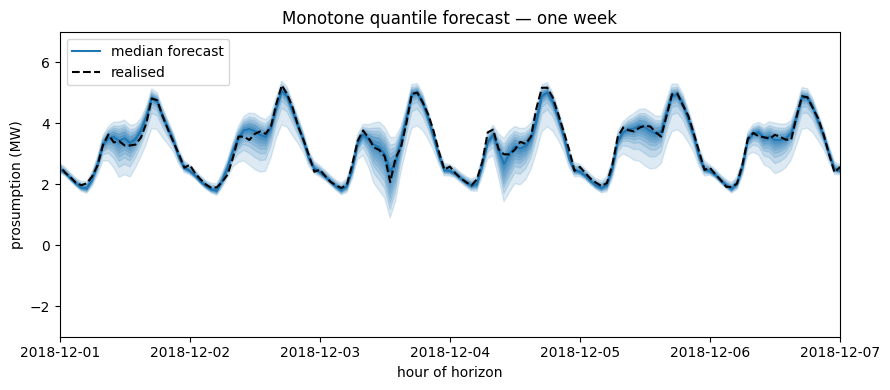

In [45]:
q_mw = denormalise_y(predictions, sc)
qp = q_mw.reshape(-1, 19)
print("qp.shape:", qp.shape)

time_idx = pd.date_range(start=deliv_start, end=deliv_end, freq="1h")

Yva = y.flatten()
mid = len(QUANTILE_LEVELS) // 2
plt.figure(figsize=(9, 4))
for k in range(mid):  # nested prediction bands
    plt.fill_between(time_idx, qp[:, k], qp[:, -1 - k], alpha=0.15, color="C0")
plt.plot(time_idx, qp[:, mid], color="C0", label="median forecast")
plt.plot(time_idx, Yva, "k--", label="realised")
plt.xlabel("hour of horizon")
plt.ylabel("prosumption (MW)")
plt.title("Monotone quantile forecast — one week")

plt.xlim(pd.Timestamp("2018-12-01 00:00:00+0000"), pd.Timestamp("2018-12-07 00:00:00+0000"))

#Timestamp('2018-01-01 00:00:00+0000', tz='UTC'),
#Timestamp('2018-12-31 23:00:00+0000', tz='UTC'),

plt.legend()
plt.tight_layout()
plt.show()

### 3.1 · Representative week per season (forecast sanity check)

Pick, for each season, the Monday→Sunday week whose median forecast is closest to the
seasonal median, and plot the quantile fan against realised. A visual check that the
marginals look sensible across the year before any copula work.

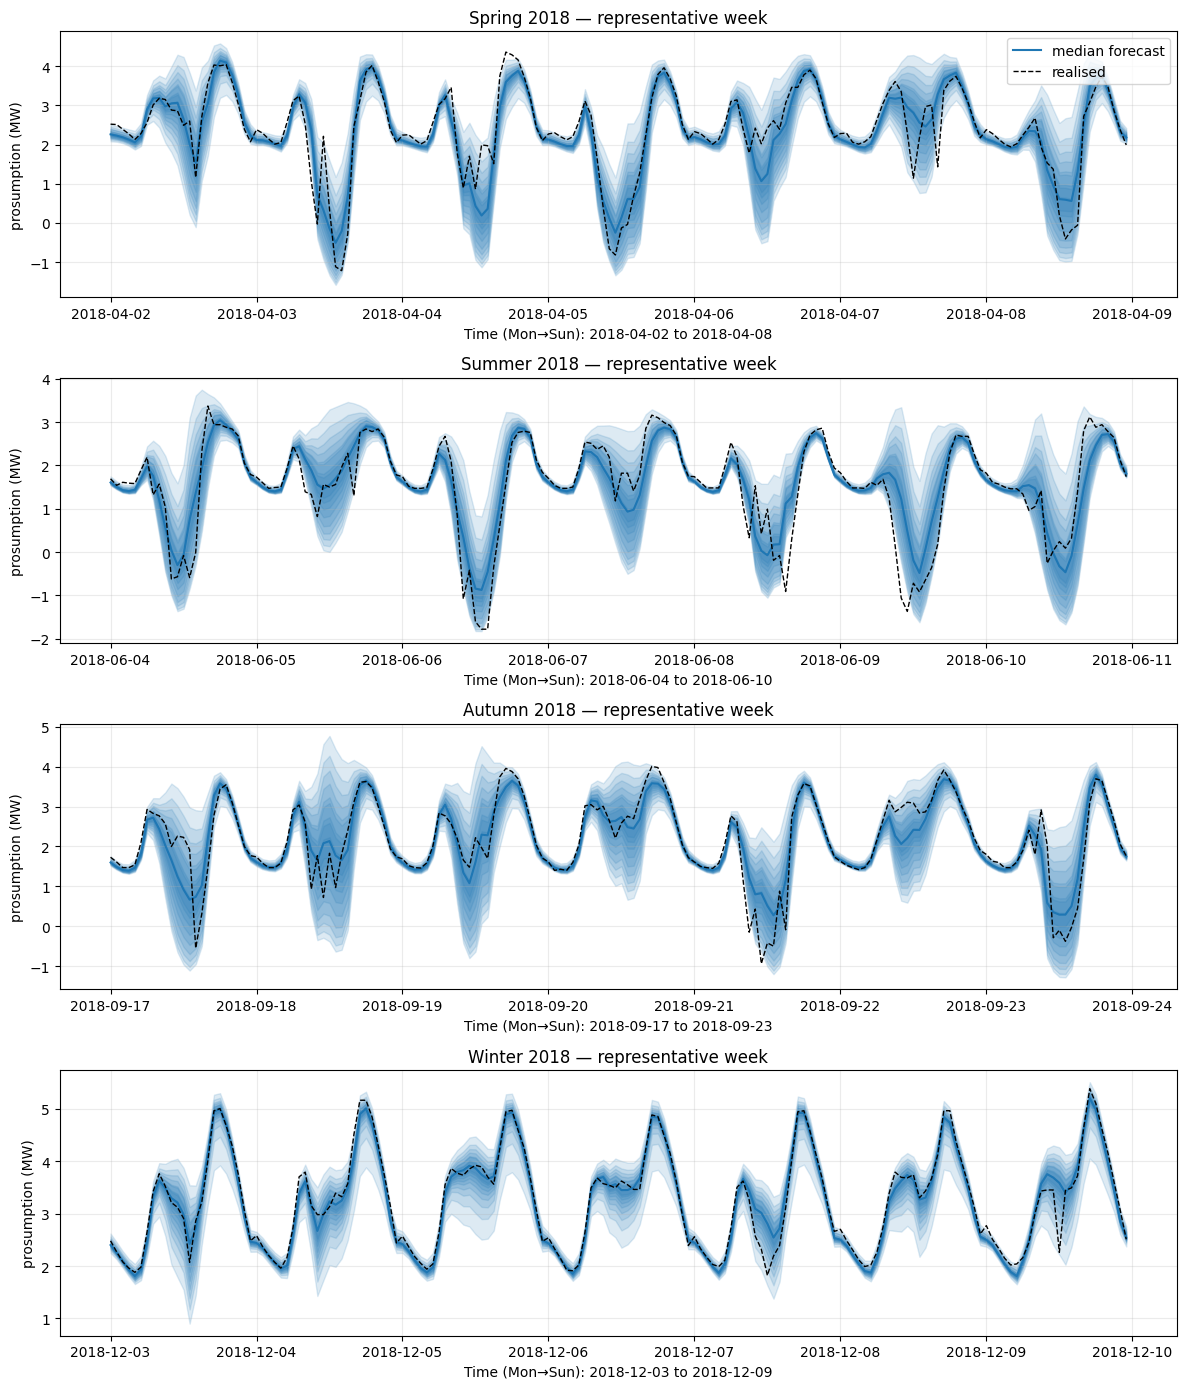

In [46]:
mid = len(QUANTILE_LEVELS) // 2
window = 7 * 24  # 168 hours

season_map = {
    "Spring 2018": [3, 4, 5],
    "Summer 2018": [6, 7, 8],
    "Autumn 2018": [9, 10, 11],
    "Winter 2018": [12, 1, 2],
}

representative_weeks = []

for season_name, months in season_map.items():
    mask = time_idx.month.isin(months)
    t = time_idx[mask]
    y_season = Yva[mask]
    qp_season = qp[mask, :]
    
    seasonal_median = np.median(qp_season[:, mid])

    # Force week starts to be Mondays and full weeks to end on Sundays
    season_anchor = t[0].normalize() - pd.to_timedelta(t[0].weekday(), unit="D")
    week_starts = pd.date_range(
        start=season_anchor,
        end=t[-1].normalize(),
        freq="W-MON",
    )

    best_score = np.inf
    best_week_idx = None
    best_week_start = None

    for week_start in week_starts:
        week_end = week_start + pd.Timedelta(days=7)
        week_mask = (t >= week_start) & (t < week_end)
        week_idx = np.flatnonzero(week_mask)

        if len(week_idx) != window:
            continue

        week_qp = qp_season[week_idx, mid]
        score = np.mean(np.abs(week_qp - seasonal_median))

        if score < best_score:
            best_score = score
            best_week_idx = week_idx
            best_week_start = week_start

    if best_week_idx is None:
        raise ValueError(f"No full Monday→Sunday representative week found for {season_name}")

    t_week = t[best_week_idx]
    y_week = y_season[best_week_idx]
    qp_week = qp_season[best_week_idx, :]

    week_end = best_week_start + pd.Timedelta(days=6, hours=23)
    representative_weeks.append(
        (season_name, t_week, y_week, qp_week, best_week_start, week_end)
    )

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=False)
fig.subplots_adjust(hspace=0.35)

for ax, (season_name, t_week, y_week, qp_week, week_start, week_end) in zip(axes, representative_weeks):
    for k in range(mid):
        ax.fill_between(
            t_week,
            qp_week[:, k],
            qp_week[:, -1 - k],
            alpha=0.15,
            color="C0",
        )

    ax.plot(t_week, qp_week[:, mid], color="C0", linewidth=1.5, label="median forecast")
    ax.plot(t_week, y_week, "k--", linewidth=1.0, label="realised")

    ax.set_title(f"{season_name} — representative week")
    ax.set_ylabel("prosumption (MW)")
    ax.grid(alpha=0.25)

    # X-axis label explicitly shows the Monday→Sunday week window
    ax.set_xlabel(
        f"Time (Mon→Sun): {week_start.strftime('%Y-%m-%d')} to {week_end.strftime('%Y-%m-%d')}"
    )

axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4 · Copula correlation estimation

`MarginalDistCDF` turns one lead's quantile forecast into a monotone piecewise-linear
CDF / inverse-CDF, with **slope-extrapolated tails** (no clamping) so the transform is
defined on all of `[0,1]`. `build_probit_matrix` applies the probability-integral
transform + probit to the realised errors, giving standard-normal scores `X (N, K)` whose
correlation is the Gaussian-copula dependence matrix.

### 4.1 · Annual correlation matrix (the working choice)

Pool all of 2018 into a single `(24, 24)` correlation of probit scores. This is the
matrix frozen for scenario generation. Seasonal / EWMA covariance were examined (below)
but the annual matrix is used for now.

In [47]:
quantiles = q_mw.reshape(-1,24,19)
X = build_probit_matrix(y, quantiles, levels=QUANTILE_LEVELS)
year_corr_matrix = np.corrcoef(np.asarray(X, dtype=float), rowvar=False)   # (K, K)
np.save(COPULA_SAVE_DIR / 'year_corr_matrix.npy', year_corr_matrix)

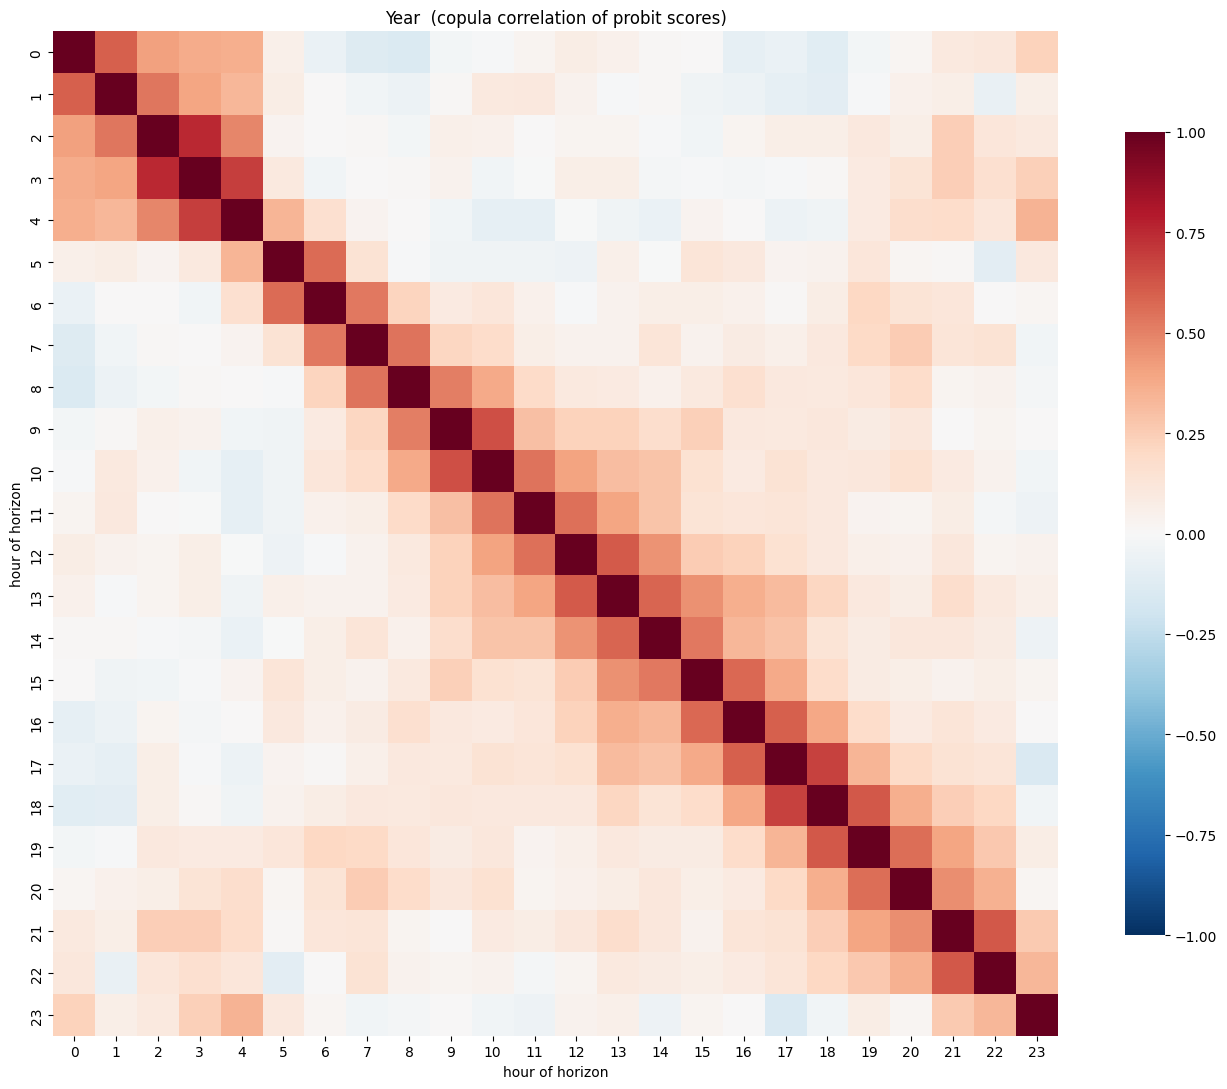

In [48]:
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(year_corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r",
            square=True, cbar_kws={"shrink": 0.8},
            xticklabels=range(24), yticklabels=range(24))
ax.set_title(f"Year  (copula correlation of probit scores)")
ax.set_xlabel("hour of horizon")
ax.set_ylabel("hour of horizon")
plt.tight_layout()
plt.show()

In [49]:
year_corr_matrix.shape

(24, 24)

### 4.2 · Seasonal correlation (diagnostic only — not frozen)

Split the probit scores by meteorological season and inspect how the dependence structure
shifts across the year. Documented as a limitation of the single annual matrix; not used
for generation at this stage.

Winter: 90 days
Spring: 92 days
Summer: 92 days
Autumn: 91 days


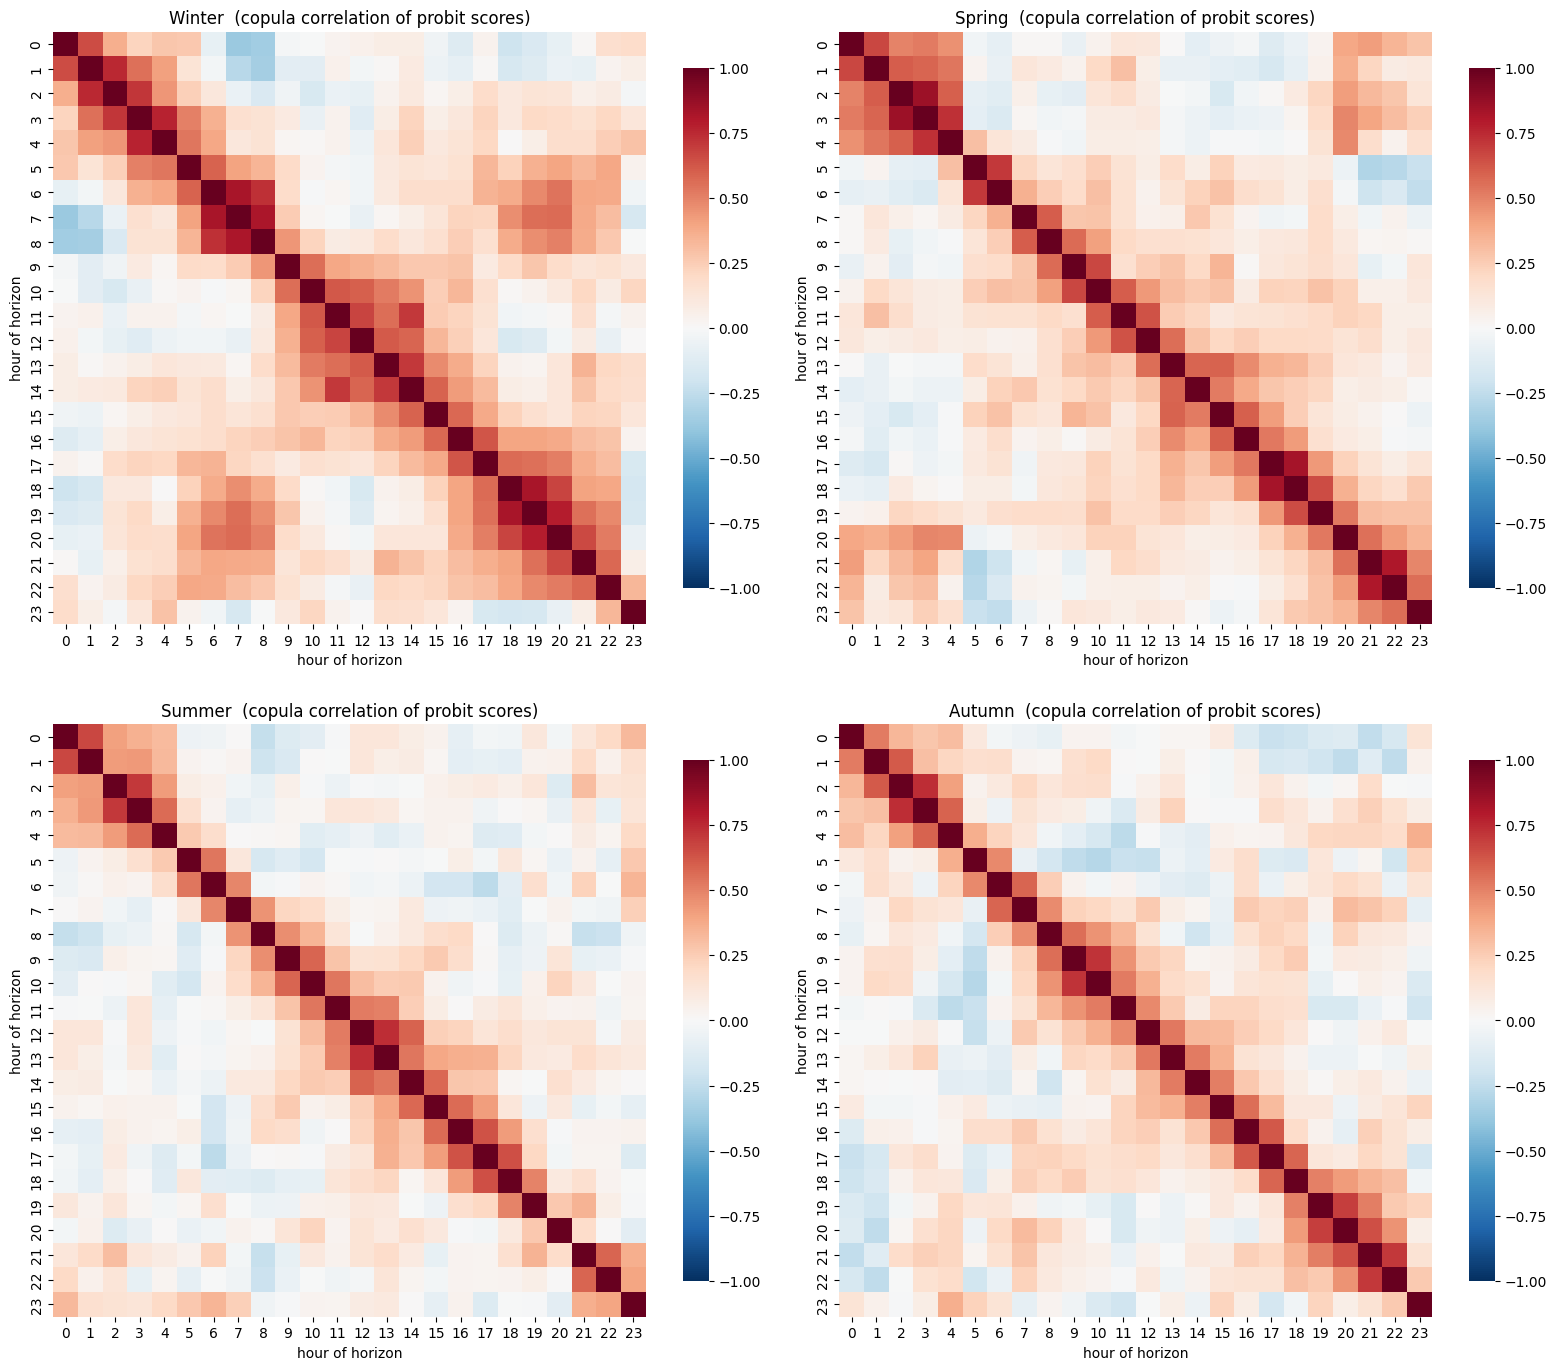

In [50]:
mats = seasonal_correlation_matrices(X, year=2018)   # pass dates=... if you have them
plot_seasonal_correlations(mats)


## 5 · Frozen correlated draws (`Z_corr`)

Draw `S` low-discrepancy Sobol points in `[0,1]^K`, map to standard normal, and correlate
with the Cholesky factor of the annual correlation matrix. These draws are **frozen** for
the entire DFL run — they fix each scenario's rank structure; only the forecaster's
quantile *values* change during training.

In [51]:
Z_corr = build_Z_corr(year_corr_matrix, K=24, seed=SEED, n=64, eps=1e-6)


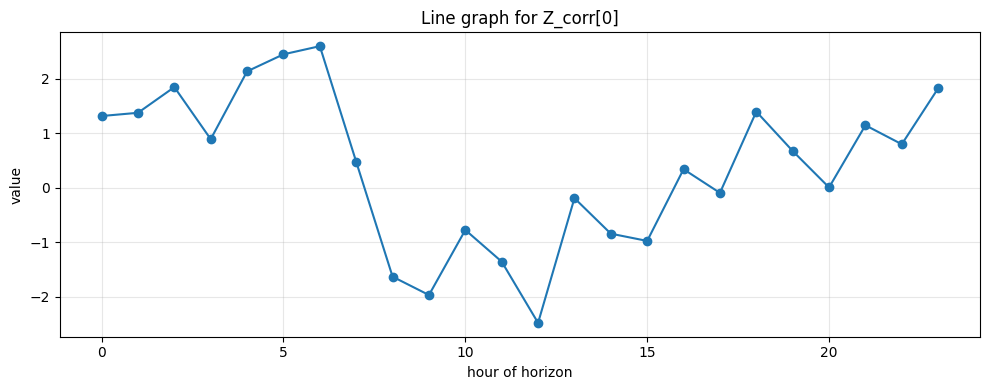

In [52]:
n = 0
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(Z_corr[n])), Z_corr[n], marker="o", linewidth=1.5)
plt.xlabel("hour of horizon")
plt.ylabel("value")
plt.title(f"Line graph for Z_corr[{str(n)}]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6 · `FrozenCopulaSampler` (differentiable generation)

`_precompute_plan` maps each frozen draw to a (bracket-index, weight) against the augmented
`[0, levels, 1]` grid — computed once, independent of the forecast values.
`FrozenCopulaSampler.prosumption` interpolates the **current** quantiles through that frozen
plan, differentiable in the quantiles and constant in `Σ`/draws. Tails are slope-extrapolated
to match `MarginalDistCDF`.

## 7 · Scenario validation

Visual and statistical checks that the generated scenarios are coherent day-paths, respect
the marginals, and are calibrated against realised trajectories.

### 7.1 · Scenarios vs quantile fan (single day)

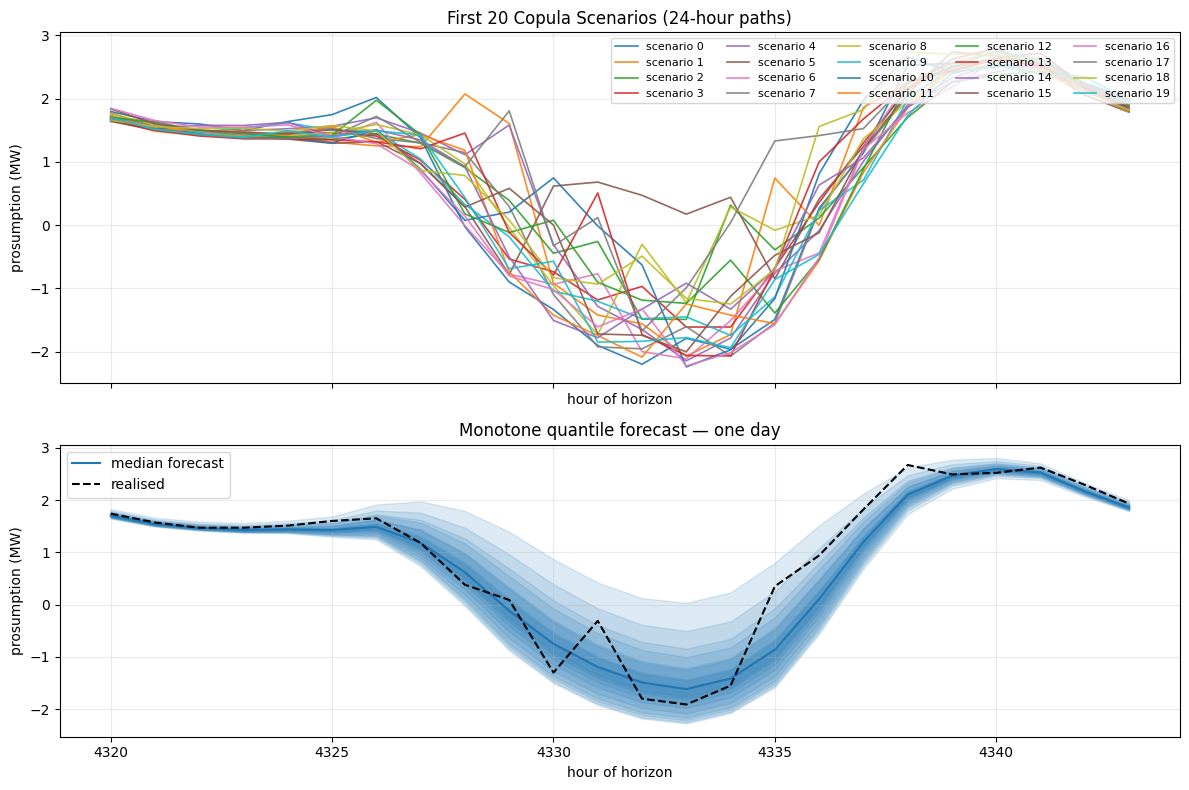

In [53]:
idx = 180

quantiles_t = torch.as_tensor(quantiles[idx, :, :], dtype=torch.float32, device=DEVICE)

sampler = FrozenCopulaSampler(Z_corr, QUANTILE_LEVELS)
scenarios = sampler.prosumption(quantiles_t)
scenario_array = scenarios.detach().cpu().numpy()

day_idx = idx
hours_per_day = 24
start_idx = day_idx * hours_per_day
end_idx = start_idx + hours_per_day
time_axis = np.arange(start_idx, end_idx)

qp_day = qp[start_idx:end_idx, :]
Yva_day = Yva[start_idx:end_idx]
               
fig, (ax_scen, ax_day) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [1.2, 1.0]}
)

# Top subplot: scenario paths
for i in range(min(20, scenario_array.shape[0])):
    ax_scen.plot(time_axis, scenario_array[i], linewidth=1.2, alpha=0.9)

ax_scen.set_xlabel("hour of horizon")
ax_scen.set_ylabel("prosumption (MW)")
ax_scen.set_title("First 20 Copula Scenarios (24-hour paths)")
ax_scen.grid(alpha=0.25)
ax_scen.legend(
    [f"scenario {i}" for i in range(min(20, scenario_array.shape[0]))],
    loc="upper right", ncol=5, fontsize=8
)

# Bottom subplot: quantile forecast + realised
for k in range(mid):
    ax_day.fill_between(time_axis, qp_day[:, k], qp_day[:, -1 - k], alpha=0.15, color="C0")

ax_day.plot(time_axis, qp_day[:, mid], color="C0", label="median forecast")
ax_day.plot(time_axis, Yva_day, "k--", label="realised")
ax_day.set_xlabel("hour of horizon")
ax_day.set_ylabel("prosumption (MW)")
ax_day.set_title("Monotone quantile forecast — one day")
ax_day.legend()
ax_day.grid(alpha=0.25)

fig.tight_layout()
plt.show()

### 7.2 · Representative day per season — forecast vs scenarios

Delivery dates are taken from the **actual** window range (`deliv_start`/`deliv_end`), not
an assumed Jan-1 start, so season labels are correct even if any days were dropped.

In [54]:
len(x_hist), deliv_start, deliv_end

(365,
 Timestamp('2018-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2018-12-31 23:00:00+0000', tz='UTC'))

In [55]:
delta = deliv_end - deliv_start
print("timedelta:", delta)
print("days:", delta.days + 1)

timedelta: 364 days 23:00:00
days: 365


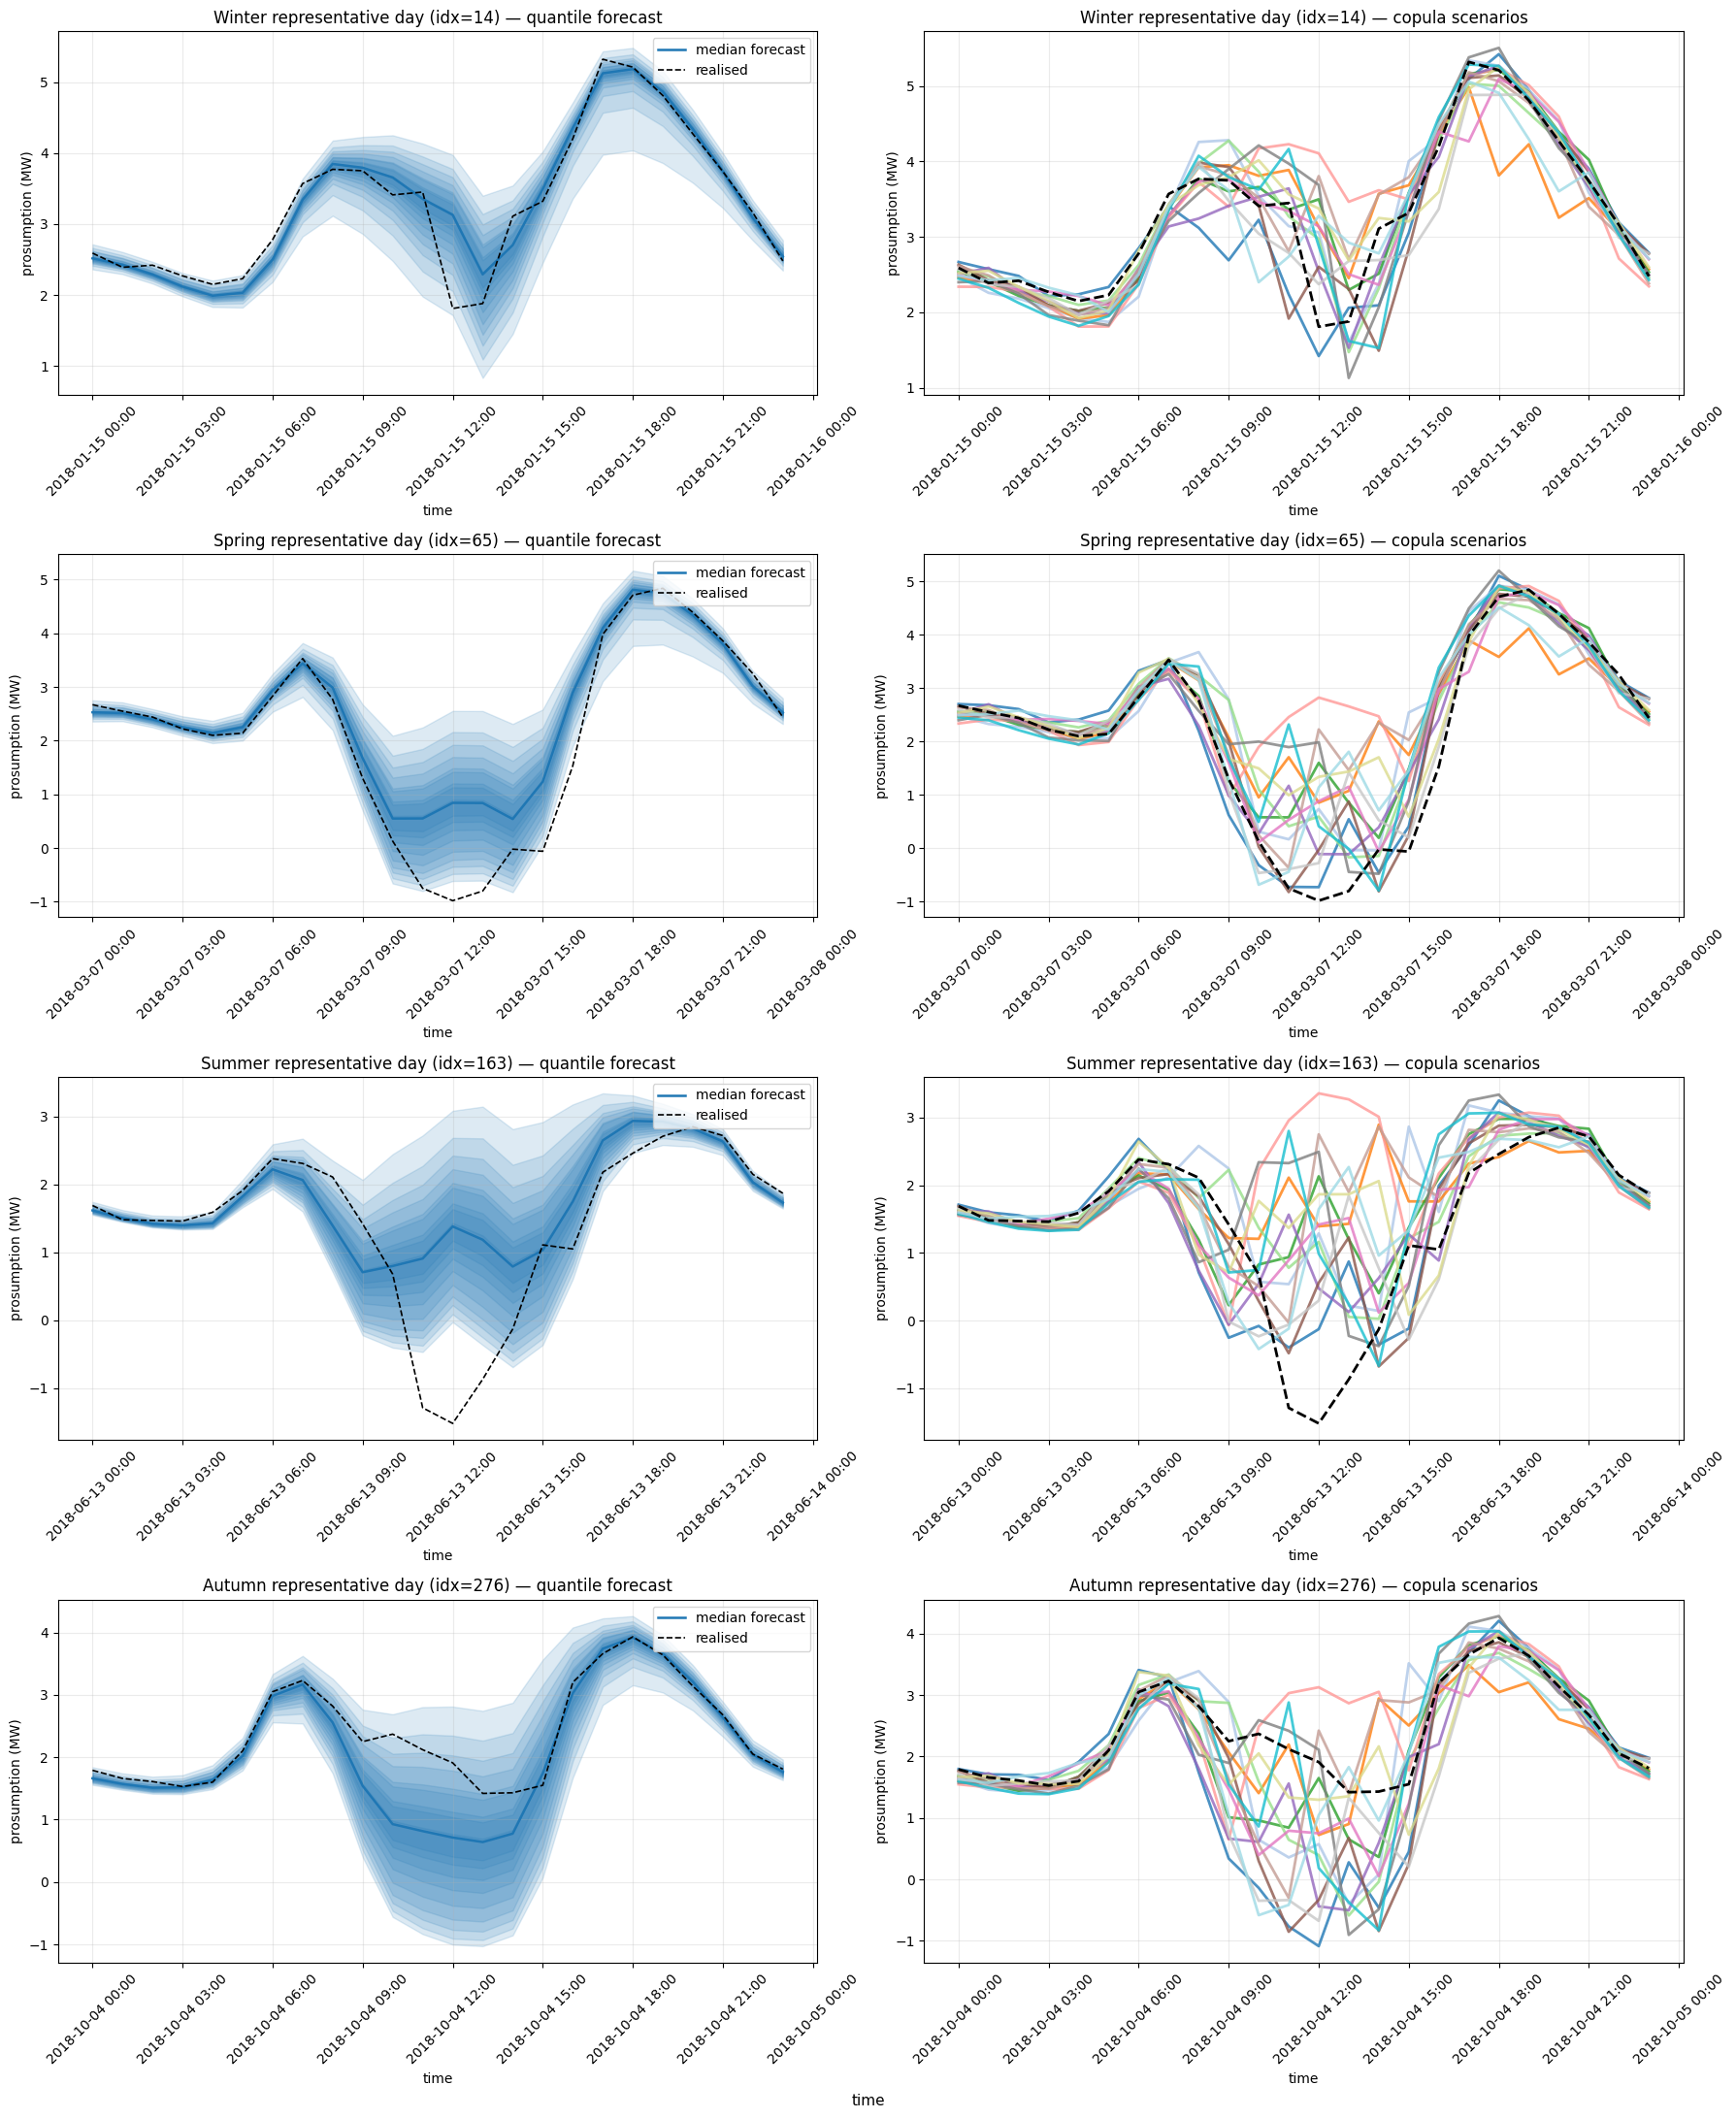

In [56]:
import matplotlib.dates as mdates

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_map = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
}

# Delimit the study period from the actual delivery window
data_start_day = pd.Timestamp(deliv_start).normalize()
data_end_day = pd.Timestamp(deliv_end).normalize()

days = pd.date_range(start=data_start_day, end=data_end_day, freq="D")
assert len(days) == y.shape[0], (
    f"Expected {y.shape[0]} daily rows from {data_start_day} to {data_end_day}, "
    f"got {len(days)} dates instead."
)

# Build representative day index per season using the actual date range
season_idx = {}
for season, months in season_map.items():
    mask = days.month.isin(months)
    day_candidates = np.flatnonzero(mask)
    daily_totals = y[day_candidates].sum(axis=1)
    med_total = np.median(daily_totals)
    best_day = day_candidates[np.argmin(np.abs(daily_totals - med_total))]
    season_idx[season] = int(best_day)

# Plot setup: 4 seasons × 2 graphs
fig, axes = plt.subplots(4, 2, figsize=(18, 22), sharex=False)
fig.subplots_adjust(hspace=0.45, wspace=0.22)

for row, season in enumerate(season_order):
    idx = season_idx[season]
    day_slice = slice(idx * 24, (idx + 1) * 24)

    time_axis = time_idx[day_slice]
    qp_day = qp[day_slice, :]
    y_day = y[idx]
    q_day = quantiles[idx, :, :]  # day-level forecast quantiles

    # Left subplot: forecast bands + realised day
    ax_fc = axes[row, 0]
    for k in range(mid):
        ax_fc.fill_between(
            time_axis,
            qp_day[:, k],
            qp_day[:, -1 - k],
            alpha=0.15,
            color="C0",
        )
    ax_fc.plot(time_axis, qp_day[:, mid], color="C0", linewidth=1.8, label="median forecast")
    ax_fc.plot(time_axis, y_day, "k--", linewidth=1.2, label="realised")
    ax_fc.set_title(f"{season} representative day (idx={idx}) — quantile forecast")
    ax_fc.set_ylabel("prosumption (MW)")
    ax_fc.grid(alpha=0.25)
    ax_fc.legend(loc="upper right")
    ax_fc.set_xlabel("time")
    ax_fc.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    ax_fc.tick_params(axis="x", rotation=45)

    # Right subplot: copula scenarios for the same representative day
    ax_sc = axes[row, 1]
    quantiles_t = torch.as_tensor(q_day, dtype=torch.float32, device=DEVICE)
    sampler = FrozenCopulaSampler(Z_corr, QUANTILE_LEVELS)
    scenarios = sampler.prosumption(quantiles_t).detach().cpu().numpy()

    n_plot = min(15, scenarios.shape[0])
    colors = plt.cm.tab20(np.linspace(0, 1, n_plot))

    for i in range(n_plot):
        ax_sc.plot(
            time_axis,
            scenarios[i],
            linewidth=2,
            alpha=0.8,
            color=colors[i],
        )

    ax_sc.plot(time_axis, y_day, "k--", linewidth=2, label="realised")
    ax_sc.set_title(f"{season} representative day (idx={idx}) — copula scenarios")
    ax_sc.set_ylabel("prosumption (MW)")
    ax_sc.grid(alpha=0.25)
    ax_sc.set_xlabel("time")
    ax_sc.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    ax_sc.tick_params(axis="x", rotation=45)

# A shared overall x-axis label for clarity
fig.supxlabel("time", fontsize=11)

plt.tight_layout()
plt.show()

### 7.3 · Multivariate calibration of scenarios

`scenario_calibration_check` reports the per-hour mean ensemble-PIT (season × hour), the
per-season multivariate rank histograms, and a midday summary (mean-PIT, outside-rate vs
expected, reliability). Flat histograms and outside-rates near expected indicate
well-calibrated scenarios.

season    midday meanPIT  midday outside-rate  expected outside  MV reliability
Winter             0.512                0.032             0.031           0.922
Spring             0.523                0.087             0.031           0.835
Summer             0.476                0.113             0.031           0.943
Autumn             0.491                0.060             0.031           0.807


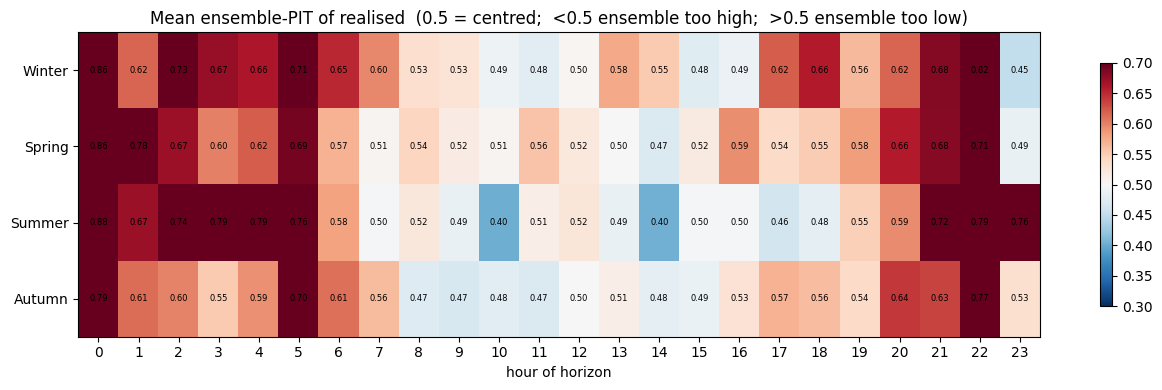

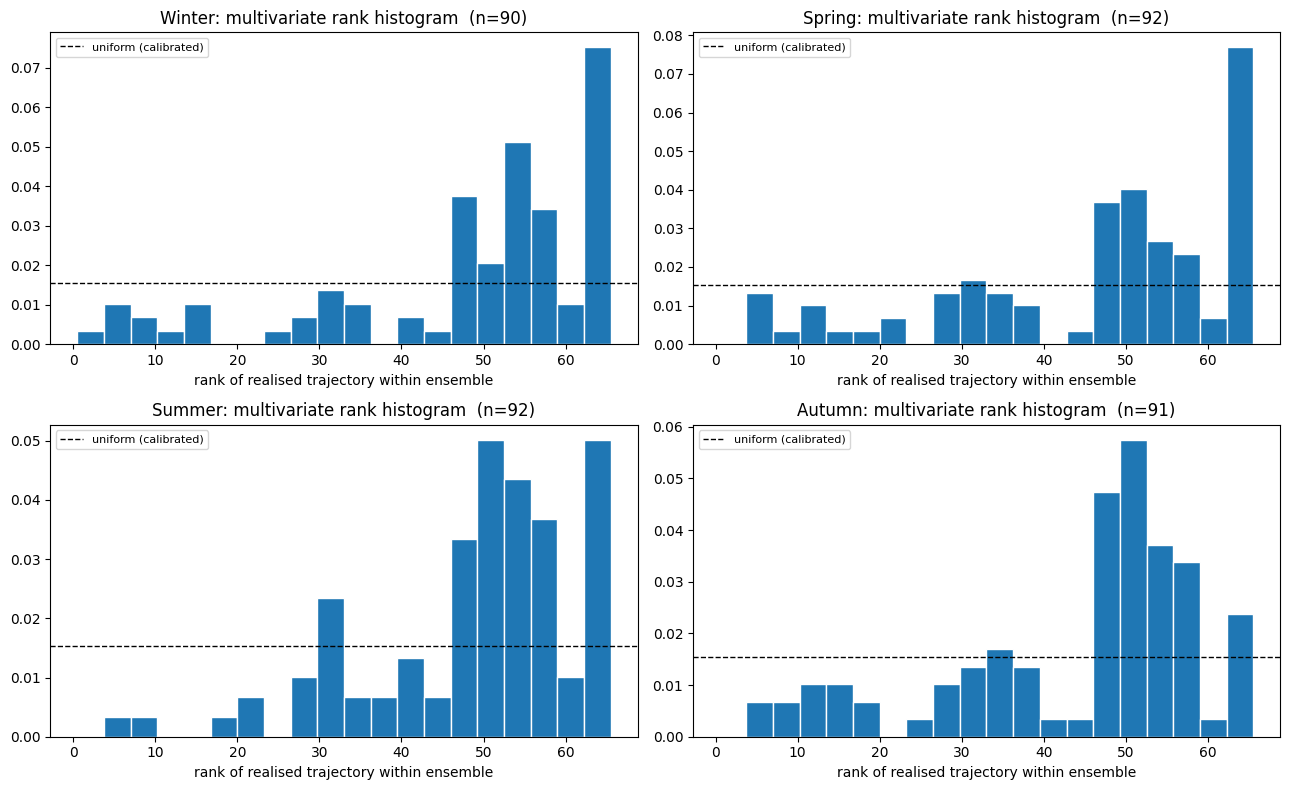

In [57]:
days = 365

# explicit sampler so this cell does not depend on execution order of earlier plot cells
sampler = FrozenCopulaSampler(Z_corr, QUANTILE_LEVELS).to(DEVICE)

scenario_grid = []

for day in range(days):
    quantiles_t = torch.as_tensor(quantiles[day, :, :], dtype=torch.float32, device=DEVICE)
    scenarios = sampler.prosumption(quantiles_t)
    scenario_grid.append(scenarios.detach().cpu().numpy())

scenario_grid = np.stack(scenario_grid, axis=0)
out = scenario_calibration_check(y, scenario_grid, year=2018)   # scenarios (N,S,24)


season    midday meanPIT midday |coverage-bias|
Winter             0.511                  0.047
Spring             0.524                  0.047
Summer             0.476                  0.048
Autumn             0.489                  0.036


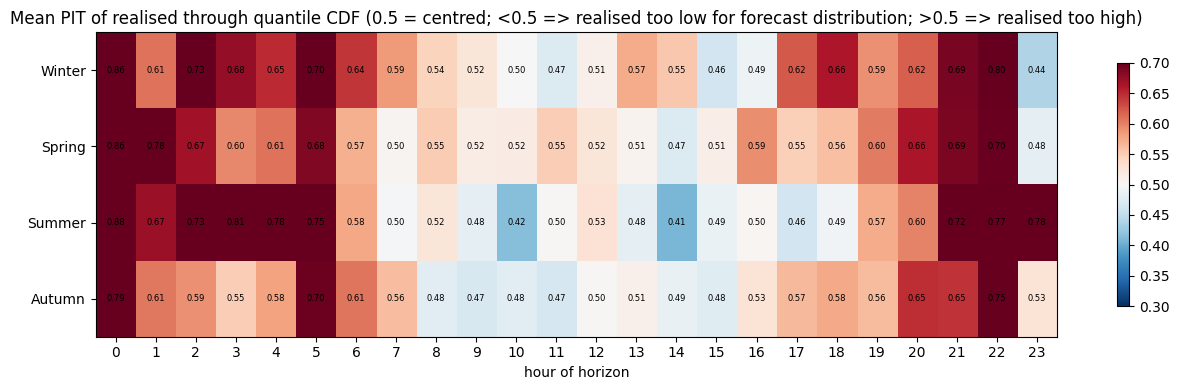

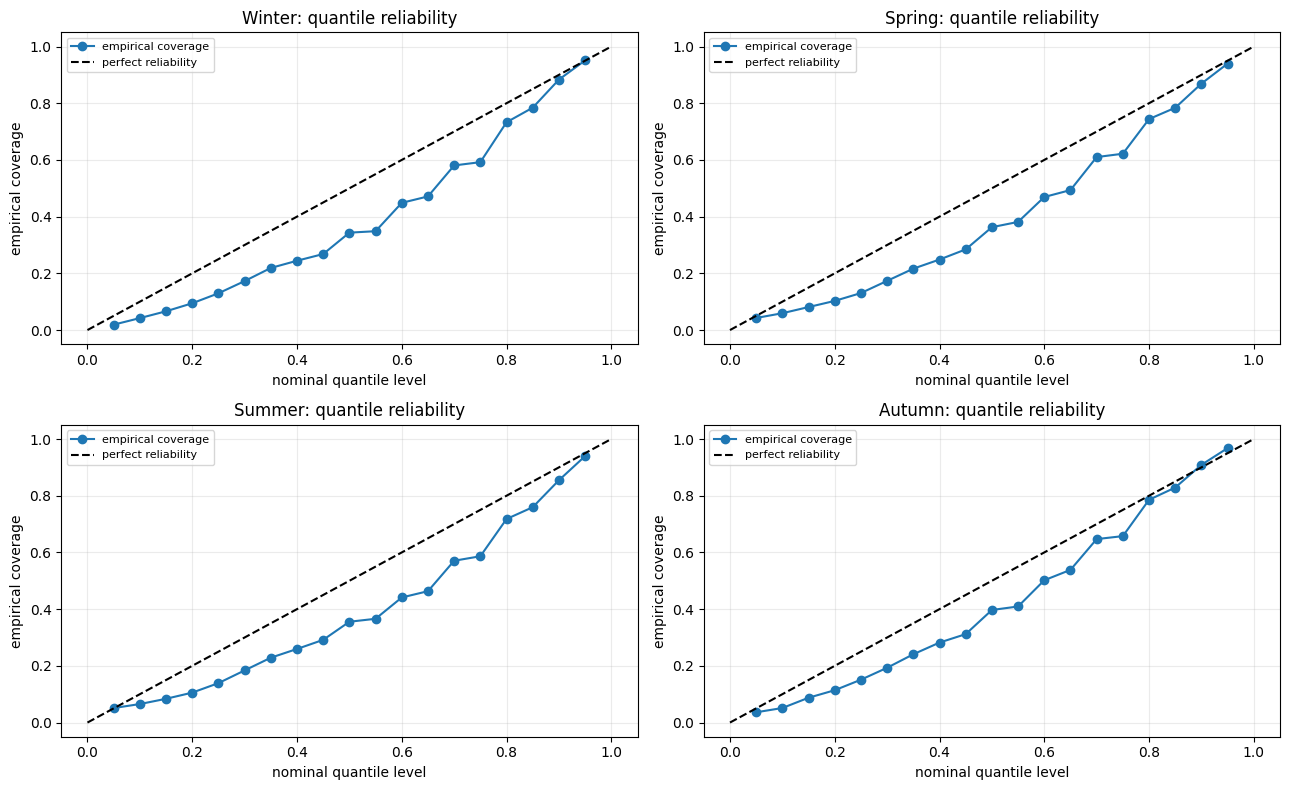

In [58]:
data_start_day = pd.Timestamp(deliv_start).normalize()
data_end_day = pd.Timestamp(deliv_end).normalize()

days = pd.date_range(start=data_start_day, end=data_end_day, freq="D")

# Example usage in this notebook:
out = quantile_reliability_check(y, quantiles, dates=days, year=2018, levels=QUANTILE_LEVELS)

## 8 · DFL-readiness checks

Three checks the optimiser depends on but which the validation above does not exercise:
the `errors()` path (scenario deviations from the forecast median), end-to-end **gradient
flow** through the sampler into the quantiles, and a **batched-over-days** generator for the
training loop. None of these change the functions above — they only test and package them.

### 8.1 · `errors_median()` path (changed important one to error_mean now but cba to test)

`errors_median()` returns scenario **deviations from the forecast median** (`scenario − q_median`).
This is forecast-relative — it does **not** use the realised value. Confirm it returns
`(S, K)`, equals `prosumption() − q_median` exactly (using the un-augmented median index
`med_idx_q`, guarding the augmented-vs-un-augmented off-by-one), and that the deviation
column is centred near — but not exactly at — zero (no Sobol draw lands exactly at
`u = 0.5`, so the median scenario is not identical to `q_median`).

In [59]:
# --- errors_mean() path test  (convention A: scenario - forecast median) ---
idx_day = 180
q_day_t = torch.as_tensor(quantiles[idx_day], dtype=torch.float32, device=DEVICE)  # (K, Q)

sampler = FrozenCopulaSampler(Z_corr, QUANTILE_LEVELS).to(DEVICE)

p = sampler.prosumption(q_day_t)     # (S, K) prosumption-level scenarios
e_median = sampler.errors_median(q_day_t)          # (S, K) deviations from the forecast median


# 1) shape
assert e_median.shape == (sampler.S, sampler.K), f"errors shape {tuple(e.shape)}"

# 2) definition: errors == prosumption - forecast median, using the UN-augmented median index
med = q_day_t[:, sampler.med_idx_q]                       # (K,)
assert torch.allclose(e_median, p - med.unsqueeze(0), atol=1e-6), "errors_mean() != prosumption - q_median"

# 3) the median index really is the 0.5 level (guards the augmented-vs-un-augmented off-by-one).
#    Index the sampler's OWN levels so the check is self-consistent regardless of which
#    global QUANTILE_LEVELS is live.
med_level = float(sampler.levels_t[sampler.med_idx_q])
assert abs(med_level - 0.50) < 1e-9, f"med_idx_q points at level {med_level}, not 0.50"

# 4) the median-deviation column is centred near zero (the cloud straddles the forecast median).
#    Not exactly zero: no draw sits exactly at u=0.5, so the median SCENARIO != q_median.
mean_err   = e_median.mean(dim=0).detach().cpu().numpy()          # (K,) mean deviation per lead
median_err = e_median.median(dim=0).values.detach().cpu().numpy() # (K,) median deviation per lead
print("errors() OK | shape:", tuple(e_median.shape))
print("med_idx_q:", sampler.med_idx_q, "-> level", med_level)
print("per-lead MEAN scenario deviation from median (MW):")
print(np.round(mean_err, 3))
print("per-lead MEDIAN scenario deviation from median (MW):")
print(np.round(median_err, 3))
print("overall mean |deviation| (MW):", float(e_median.abs().mean()))

errors() OK | shape: (64, 24)
med_idx_q: 9 -> level 0.5
per-lead MEAN scenario deviation from median (MW):
[0.011 0.011 0.011 0.014 0.015 0.019 0.022 0.037 0.056 0.073 0.107 0.091
 0.09  0.112 0.124 0.112 0.073 0.046 0.019 0.01  0.004 0.003 0.007 0.011]
per-lead MEDIAN scenario deviation from median (MW):
[-0.003 -0.001 -0.004 -0.012 -0.004 -0.005  0.004 -0.038  0.002  0.001
 -0.079 -0.092 -0.07   0.001 -0.052 -0.04   0.017  0.001  0.003  0.02
  0.001  0.     0.001 -0.009]
overall mean |deviation| (MW): 0.2722484767436981


### 8.2 · Gradient flow through the sampler

The whole point of the differentiable sampler is that decision-loss gradients reach the
forecaster's quantiles. Verify that:

1. a scalar built from `prosumption` produces a **finite, non-zero** `quantiles.grad`;
2. the **tail quantiles** (`[:,0]` and `[:,-1]`) receive gradient — they feed the
   slope-extrapolated endpoints, so a zero there would mean the tails are detached;
3. gradients also flow through the `errors()` path;
4. autograd matches a finite-difference estimate on a random scalar (correctness, not just
   non-zero-ness).

In [60]:
# --- gradient-flow tests ---
sampler = FrozenCopulaSampler(Z_corr, QUANTILE_LEVELS).to(DEVICE)

q = torch.as_tensor(quantiles[180], dtype=torch.float64, device=DEVICE)  # float64 for FD check
q.requires_grad_(True)

# 1) gradient exists, finite, non-zero
scen = sampler.prosumption(q)                 # (S, K)
loss = scen.pow(2).sum()
loss.backward()
g = q.grad
assert g is not None,           "quantiles.grad is None -- graph is broken"
assert torch.isfinite(g).all(), "non-finite gradient"
assert g.abs().sum() > 0,       "all-zero gradient -- nothing would train"
print("[1] grad finite & non-zero  | grad abs-sum:", float(g.abs().sum()))

# 2) tails receive gradient (extrapolated endpoints stay connected).
#    NOTE: this really tests "some Sobol draw landed in the tail"; at S=256 that is
#    ~13 draws beyond each outer quantile, so it passes. The FD check [4] is the real
#    correctness guarantee for the interpolation/extrapolation.
tail_lo = g[:, 0].abs().sum().item()
tail_hi = g[:, -1].abs().sum().item()
print(f"[2] tail grad  low={tail_lo:.4g}  high={tail_hi:.4g}")
assert tail_lo > 0 and tail_hi > 0, "tail quantiles detached -- DFL cannot move the tails"

# 3) errors_mean() path is differentiable too
q2 = torch.as_tensor(quantiles[180], dtype=torch.float32, device=DEVICE).requires_grad_()
sampler.errors_mean(q2).pow(2).sum().backward()
assert q2.grad is not None and q2.grad.abs().sum() > 0, "errors() path not differentiable"
print("[3] errors_mean() path differentiable | grad abs-sum:", float(q2.grad.abs().sum()))

# 4) finite-difference check against autograd on the scalar (prosumption**2).sum()
q3 = torch.as_tensor(quantiles[180], dtype=torch.float64, device=DEVICE).requires_grad_()
def scalar(qq):
    return (sampler.prosumption(qq) ** 2).sum()

loss3 = scalar(q3)
loss3.backward()
ana = q3.grad.clone()

eps = 1e-6
num = torch.zeros_like(q3)
base = float(scalar(q3.detach()))
for i in range(q3.shape[0]):
    for j in range(q3.shape[1]):
        pert = q3.detach().clone()
        pert[i, j] += eps
        num[i, j] = (float(scalar(pert)) - base) / eps
rel = (ana - num).abs().max() / (num.abs().max() + 1e-12)
print(f"[4] autograd vs finite-diff  max rel err: {float(rel):.2e}")
assert rel < 1e-4, "autograd disagrees with finite differences"
print("all gradient checks passed.")

[1] grad finite & non-zero  | grad abs-sum: 4636.729198510536
[2] tail grad  low=496.9  high=522.3
[3] errors_mean() path differentiable | grad abs-sum: 880.154296875
[4] autograd vs finite-diff  max rel err: 3.40e-07
all gradient checks passed.


### 8.3 · Batched-over-days generation

`prosumption` handles one day `(K, Q)`. Inside the DFL loop it is cheaper to generate
scenarios for a batch of days at once. `prosumption_batched` below broadcasts the frozen
plan over a `(D, K, Q)` batch and returns `(D, S, K)` — **fully differentiable**, no Python
loop over days. It reuses the exact same augmented-grid + gather logic as the single-day
method, so results match the per-day loop.

Note: the frozen `idx`/`w` are `(S, K)` and are shared across all days (same draws every
day), so they broadcast over the batch axis directly.

In [61]:
# --- verify batched == per-day loop, and that it is differentiable ---
sampler = FrozenCopulaSampler(Z_corr, QUANTILE_LEVELS).to(DEVICE)

D = 8
qb = torch.as_tensor(quantiles[:D], dtype=torch.float32, device=DEVICE)     # (D,K,Q)
batched = prosumption_batched(sampler, qb)                                  # (D,S,K)

# reference: per-day loop using the single-day method
ref = torch.stack([sampler.prosumption(qb[d]) for d in range(D)], dim=0)    # (D,S,K)
assert batched.shape == ref.shape == (D, sampler.S, sampler.K)
assert torch.allclose(batched, ref, atol=1e-5), "batched != per-day loop"
print("batched matches per-day loop | shape:", tuple(batched.shape))

# differentiability through the batched path
qb_g = torch.as_tensor(quantiles[:D], dtype=torch.float32, device=DEVICE).requires_grad_()
prosumption_batched(sampler, qb_g).pow(2).sum().backward()
assert qb_g.grad is not None and qb_g.grad.abs().sum() > 0, "batched path not differentiable"
print("batched path differentiable | grad abs-sum:", float(qb_g.grad.abs().sum()))


batched matches per-day loop | shape: (8, 64, 24)
batched path differentiable | grad abs-sum: 80010.546875


## 9 · (Optional) freeze copula artefacts

For the DFL run, persist the exact frozen copula so training reloads an identical sampler:
the annual correlation matrix, the frozen `Z_corr` draws, the quantile levels, and the
seed. Uncomment to save.

In [62]:
# --- persist the frozen copula artefacts (uncomment to write) ---
copula_bundle = {
    "year_corr_matrix": year_corr_matrix,   # (K, K) annual copula correlation
    "Z_corr":           Z_corr,             # (S, K) frozen correlated draws
    "quantile_levels":  np.asarray(QUANTILE_LEVELS, float),
    "S":                Z_corr.shape[0],
    "K":                Z_corr.shape[1],
    "seed":             SEED,
    "origin":           "gate_aligned_only=True, issue_hour=9",
    "covariance_choice":"annual (seasonal/EWMA examined, not used)",
    }

save_path = COPULA_SAVE_DIR / "frozen_copula.pkl"

with open(save_path, "wb") as f:
    pickle.dump(copula_bundle, f)
    print("saved:", save_path)


saved: /home/fleet75/diss_bess/5_scenario_gen/frozen_copula.pkl
